In [1]:
!pip install pyts

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn


In [3]:
def assess_device():
    """Return the best available device: MPS, CUDA, then CPU."""

    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return "mps"
    if torch.cuda.is_available():
        return "cuda"
    return "cpu"

device = assess_device()

## Classification

### Dataset

**Cylinder-Bell-Funnel**

This simulated dataset was introduced by N. Saito in his Ph.D. thesis entitled “Local feature extraction and its application”. It is one of the most well-known datasets in time series classification.

In [4]:
# Import the dataset
from pyts.datasets import make_cylinder_bell_funnel
X, y = make_cylinder_bell_funnel(n_samples=300, random_state=3)
print(X.shape)
X = X[:, :, np.newaxis]
print(X.shape)

(300, 128)
(300, 128, 1)


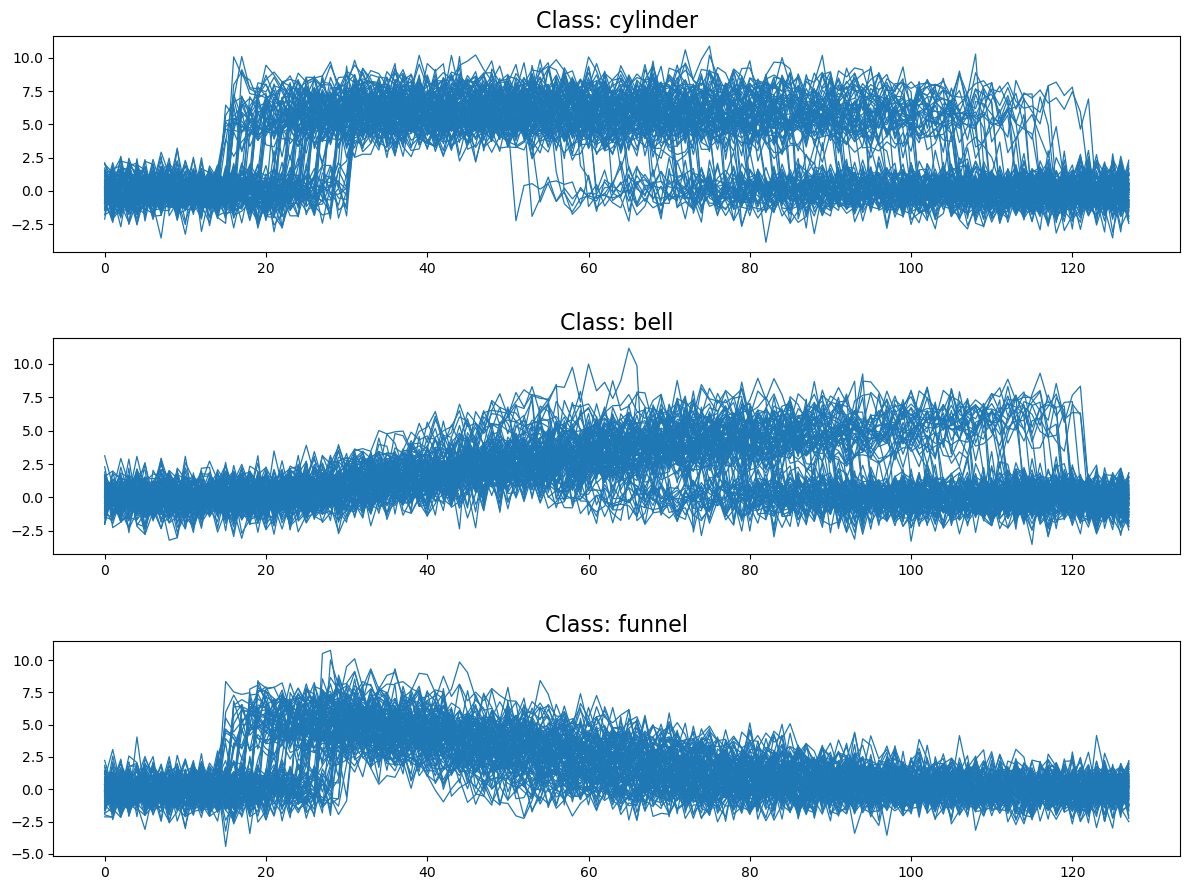

In [5]:
# Dataset visualization
plt.figure(figsize=(12, 9))
for i, classe in enumerate(['cylinder', 'bell', 'funnel']):
    plt.subplot(3, 1, i + 1)
    for x in X[y == i]:
        plt.plot(x.ravel(), color='C0', linewidth=0.9)
    plt.title('Class: {}'.format(classe), fontsize=16)

plt.tight_layout()
plt.subplots_adjust(hspace=0.4)
plt.show()

In [6]:
# Train/Test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42, stratify=y)

![](https://i.pinimg.com/originals/b6/2f/88/b62f8810c86edf0a96f1f2dbac9a3ca1.png)

Loss: Cross entropy for multiclass classification

PyTorch's `nn.CrossEntropyLoss` receives the raw class scores (logits) and the integer class labels.


$$
J(\mathbf{w}) = -\frac{1}{N}\sum_{i=1}^{N}\log\left(\frac{e^{z_{i, y_i}}}{\sum_{c=1}^{C}e^{z_{i,c}}}\right)
$$

where $z_{i,c}$ is the logit for class $c$ of observation $i$.


### Vanilla RNN

In [8]:
from torch.utils.data import DataLoader, TensorDataset, random_split

BATCH_SIZE = 32

X_train_tensor = torch.as_tensor(X_train, dtype=torch.float32).to(device)
y_train_tensor = torch.as_tensor(y_train, dtype=torch.long).to(device)
X_test_tensor = torch.as_tensor(X_test, dtype=torch.float32).to(device)
y_test_tensor = torch.as_tensor(y_test, dtype=torch.long).to(device)

train_data = TensorDataset(X_train_tensor, y_train_tensor)
test_data = TensorDataset(X_test_tensor, y_test_tensor)

train_dataloader = DataLoader(
    train_data,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_dataloader = DataLoader(
    test_data,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print(f"Dataloaders: {train_dataloader, test_dataloader}")
print(f"Length of train dataloader: {len(train_dataloader)} batches of {BATCH_SIZE}")
print(f"Length of test dataloader: {len(test_dataloader)} batches of {BATCH_SIZE}")


Dataloaders: (<torch.utils.data.dataloader.DataLoader object at 0x3041a5550>, <torch.utils.data.dataloader.DataLoader object at 0x3040c4b90>)
Length of train dataloader: 7 batches of 32
Length of test dataloader: 4 batches of 32


In [9]:
from types import SimpleNamespace

torch.manual_seed(42)
np.random.seed(42)


def summarize_model(model, input_shape):
    print(model)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Trainable parameters: {n_params:,}")
    sample = torch.zeros(input_shape, dtype=torch.float32, device=device)
    model.eval()
    with torch.inference_mode():
        output = model(sample)
    print(f"Input shape: {tuple(sample.shape)}")
    print(f"Output shape: {tuple(output.shape)}")


def _history(values):
    return SimpleNamespace(history=values)


def make_loaders(X, y, batch_size=BATCH_SIZE, validation_split=0.3, target_dtype=torch.long):
    X_tensor = torch.as_tensor(X, dtype=torch.float32)
    y_tensor = torch.as_tensor(y, dtype=target_dtype)
    dataset = TensorDataset(X_tensor, y_tensor)
    n_val = int(len(dataset) * validation_split)
    n_train = len(dataset) - n_val
    generator = torch.Generator().manual_seed(42)
    train_subset, val_subset = random_split(dataset, [n_train, n_val], generator=generator)
    train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader


def evaluate_classifier(model, dataloader, criterion=None):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    criterion = criterion or nn.CrossEntropyLoss()
    with torch.inference_mode():
        for xb, yb in dataloader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            total_loss += loss.item() * len(xb)
            correct += (logits.argmax(dim=1) == yb).sum().item()
            total += len(xb)
    return total_loss / total, correct / total


def train_classifier(model, X, y, validation_split=0.3, epochs=100, learning_rate=0.001, clipnorm=None):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    train_loader, val_loader = make_loaders(X, y, validation_split=validation_split, target_dtype=torch.long)
    values = {"loss": [], "val_loss": [], "accuracy": [], "val_accuracy": []}

    for epoch in range(epochs):
        model.train()
        total_loss, correct, total = 0.0, 0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            if clipnorm is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=clipnorm)
            optimizer.step()

            total_loss += loss.item() * len(xb)
            correct += (logits.argmax(dim=1) == yb).sum().item()
            total += len(xb)

        val_loss, val_acc = evaluate_classifier(model, val_loader, criterion)
        values["loss"].append(total_loss / total)
        values["accuracy"].append(correct / total)
        values["val_loss"].append(val_loss)
        values["val_accuracy"].append(val_acc)

    return _history(values)


def predict_classifier(model, X):
    model.eval()
    X_tensor = torch.as_tensor(X, dtype=torch.float32, device=device)
    with torch.inference_mode():
        logits = model(X_tensor)
        return torch.softmax(logits, dim=1).cpu().numpy()


def train_regressor(model, X, y, validation_split=0.3, epochs=30, learning_rate=0.001):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    train_loader, val_loader = make_loaders(X, y, validation_split=validation_split, target_dtype=torch.float32)
    values = {"loss": [], "val_loss": []}

    for epoch in range(epochs):
        model.train()
        total_loss, total = 0.0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * len(xb)
            total += len(xb)

        val_loss, val_total = 0.0, 0
        model.eval()
        with torch.inference_mode():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                pred = model(xb)
                loss = criterion(pred, yb)
                val_loss += loss.item() * len(xb)
                val_total += len(xb)

        values["loss"].append(total_loss / total)
        values["val_loss"].append(val_loss / val_total)

    return _history(values)


def predict_regressor(model, X, batch_size=BATCH_SIZE):
    X_tensor = torch.as_tensor(X, dtype=torch.float32)
    dataloader = DataLoader(TensorDataset(X_tensor), batch_size=batch_size, shuffle=False)
    preds = []
    model.eval()
    with torch.inference_mode():
        for (xb,) in dataloader:
            preds.append(model(xb.to(device)).cpu())
    return torch.cat(preds).numpy()


class RecurrentClassifier(nn.Module):
    def __init__(self, recurrent_layer, hidden_size=32, num_classes=3):
        super().__init__()
        self.recurrent = recurrent_layer
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out, hidden = self.recurrent(x)
        if isinstance(hidden, tuple):
            hidden = hidden[0]
        last_hidden = hidden[-1]
        return self.fc(last_hidden)


def init_input_identity(recurrent_layer, gain=1.0):
    with torch.no_grad():
        for name, param in recurrent_layer.named_parameters():
            if "weight_ih" in name:
                param.zero_()
                rows, cols = param.shape
                diag = min(rows, cols)
                param[:diag, :diag] = gain * torch.eye(diag, device=param.device)


In [10]:
rnn_layer = nn.RNN(
    input_size=1,
    hidden_size=32,
    num_layers=1,
    nonlinearity="tanh",
    batch_first=True
)
init_input_identity(rnn_layer, gain=1.0)
rnn = RecurrentClassifier(rnn_layer, hidden_size=32, num_classes=3).to(device)
summarize_model(rnn, input_shape=(1, 128, 1))


RecurrentClassifier(
  (recurrent): RNN(1, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=3, bias=True)
)
Trainable parameters: 1,219
Input shape: (1, 128, 1)
Output shape: (1, 3)


In [11]:
rnn

RecurrentClassifier(
  (recurrent): RNN(1, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=3, bias=True)
)

In [12]:
hist = train_classifier(rnn, X_train, y_train, validation_split=.3, epochs=500, learning_rate=0.0001, clipnorm=1)

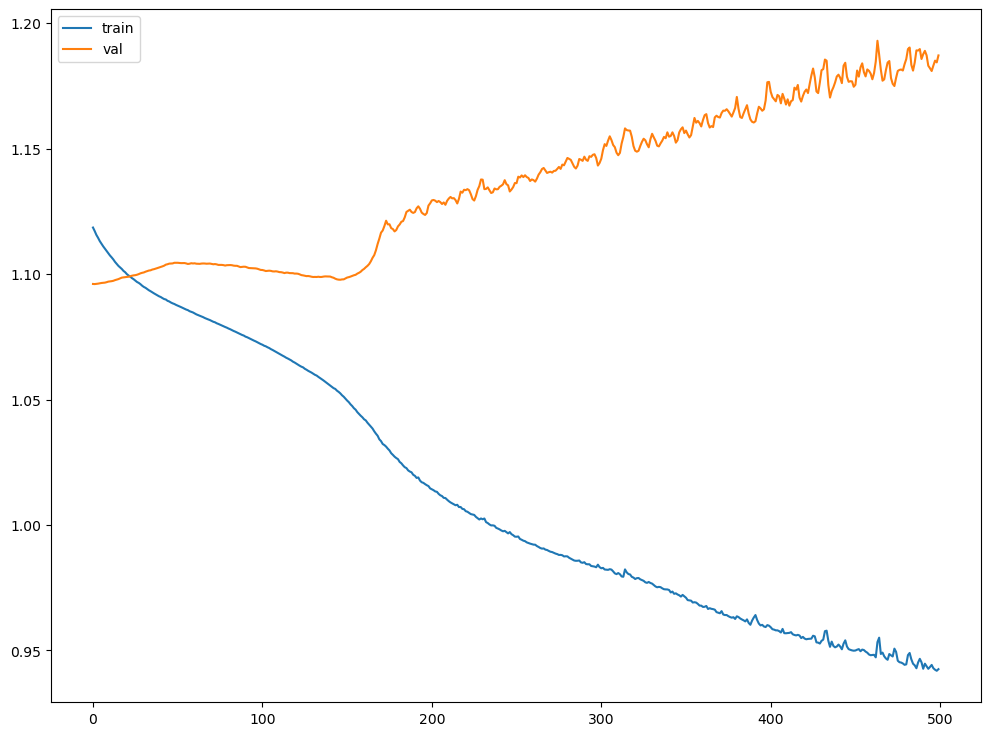

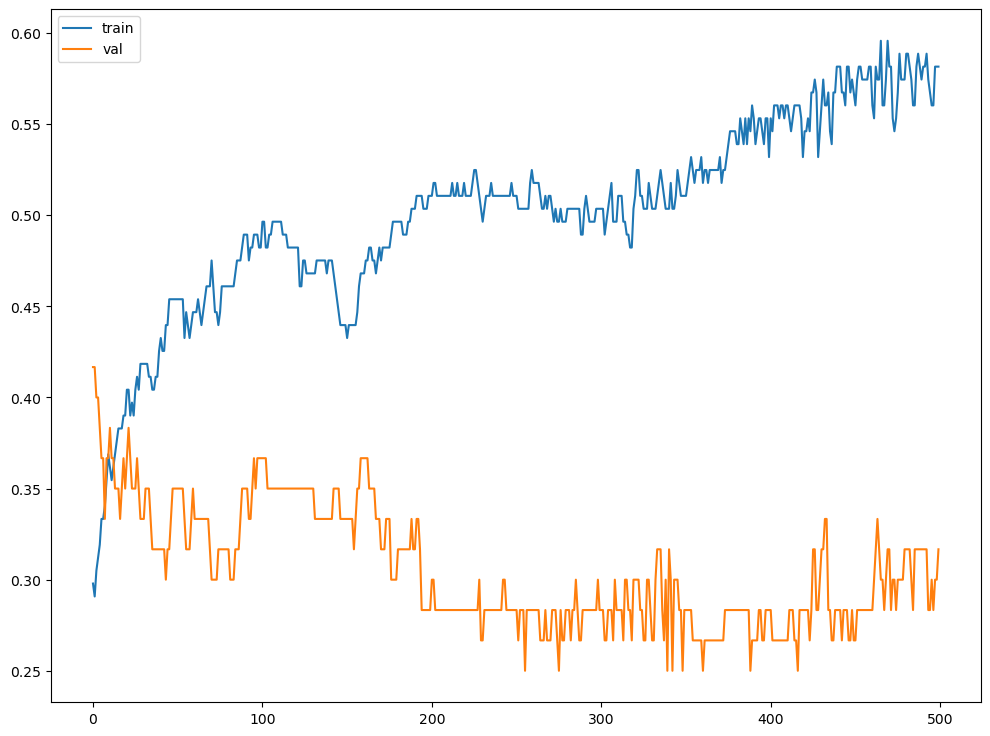

In [13]:
plt.figure(figsize=(12, 9))
plt.plot(hist.history["loss"], label="train")
plt.plot(hist.history["val_loss"], label="val")
plt.legend()
plt.show()


plt.figure(figsize=(12, 9))
plt.plot(hist.history["accuracy"], label="train")
plt.plot(hist.history["val_accuracy"], label="val")
plt.legend()
plt.show()

In [14]:
X_train.shape

(201, 128, 1)

In [15]:
evaluate_classifier(rnn, test_dataloader)

(1.267824245221687, 0.37373737373737376)

cyl: 0.326566
bell: 0.360206
fun: 0.313228



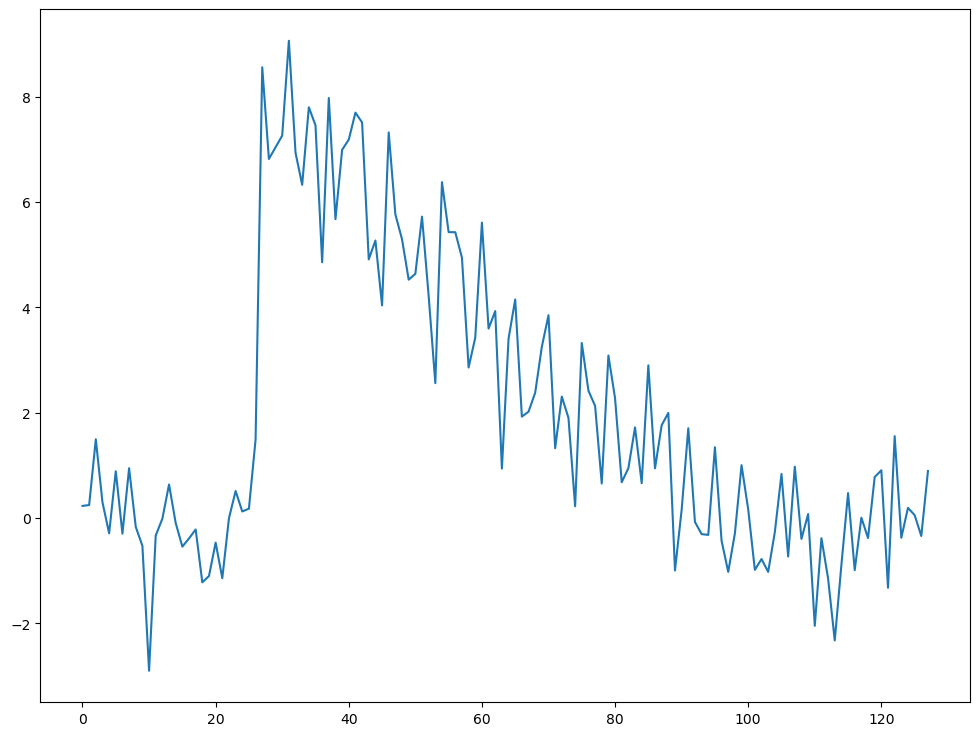

In [16]:
i = 0
pred = predict_classifier(rnn, X_train[i:i+1]).ravel()
print("cyl: %f\nbell: %f\nfun: %f\n" % (pred[0], pred[1], pred[2]))
plt.figure(figsize=(12, 9))
plt.plot(X_train[i].ravel())
plt.show()


### LSTM

In [17]:
lstm_layer = nn.LSTM(
    input_size=1,
    hidden_size=32,
    num_layers=1,
    batch_first=True
)
lstm = RecurrentClassifier(lstm_layer, hidden_size=32, num_classes=3).to(device)
summarize_model(lstm, input_shape=(1, 128, 1))


RecurrentClassifier(
  (recurrent): LSTM(1, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=3, bias=True)
)
Trainable parameters: 4,579
Input shape: (1, 128, 1)
Output shape: (1, 3)


In [20]:
hist = train_classifier(lstm, X_train, y_train, validation_split=.3, epochs=500)

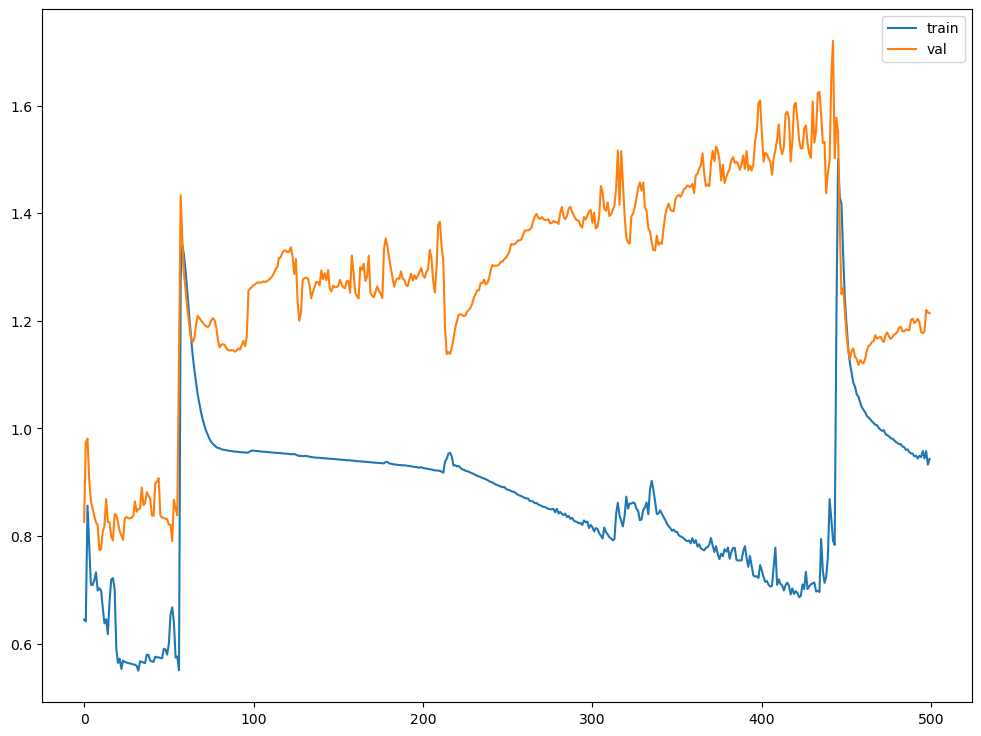

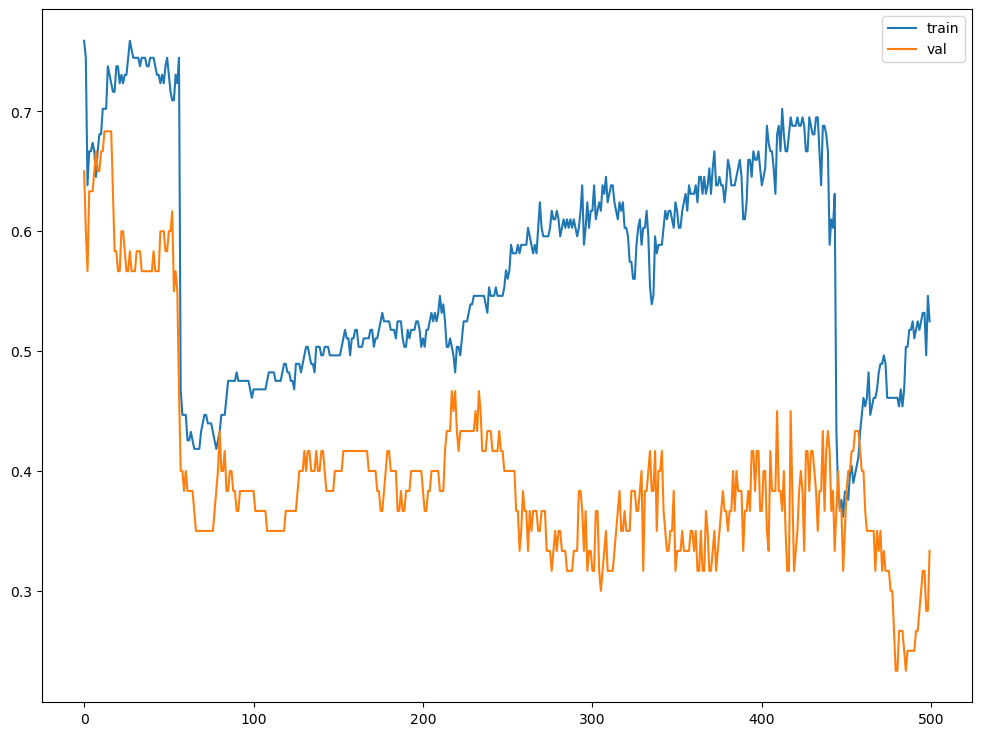

In [21]:
plt.figure(figsize=(12, 9))
plt.plot(hist.history["loss"], label="train")
plt.plot(hist.history["val_loss"], label="val")
plt.legend()
plt.show()


plt.figure(figsize=(12, 9))
plt.plot(hist.history["accuracy"], label="train")
plt.plot(hist.history["val_accuracy"], label="val")
plt.legend()
plt.show()

In [22]:
evaluate_classifier(lstm, test_dataloader)

(1.0925143222616176, 0.40404040404040403)

cyl: 0.317105
bell: 0.131626
fun: 0.551269



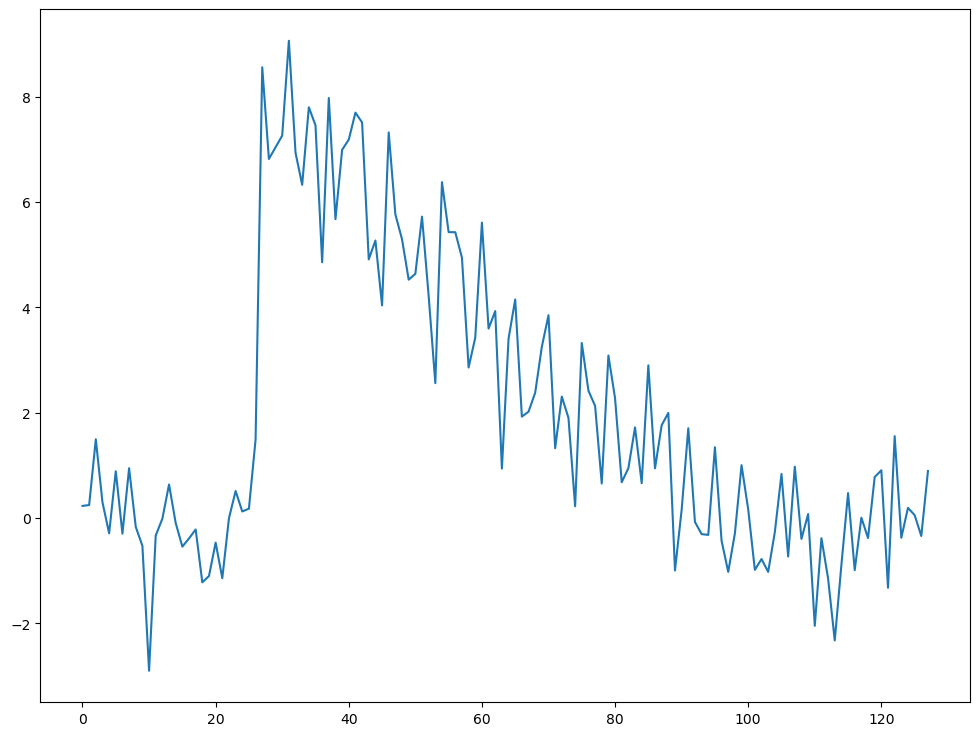

In [23]:
i = 0
pred = predict_classifier(lstm, X_train[i:i+1]).ravel()
print("cyl: %f\nbell: %f\nfun: %f\n" % (pred[0], pred[1], pred[2]))
plt.figure(figsize=(12, 9))
plt.plot(X_train[i].ravel())
plt.show()


### GRU

In [24]:
gru_layer = nn.GRU(
    input_size=1,
    hidden_size=32,
    num_layers=1,
    batch_first=True
)
init_input_identity(gru_layer, gain=1.0)
gru = RecurrentClassifier(gru_layer, hidden_size=32, num_classes=3).to(device)
summarize_model(gru, input_shape=(1, 128, 1))


RecurrentClassifier(
  (recurrent): GRU(1, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=3, bias=True)
)
Trainable parameters: 3,459
Input shape: (1, 128, 1)
Output shape: (1, 3)


In [25]:
hist = train_classifier(gru, X_train, y_train, validation_split=.3, epochs=500)

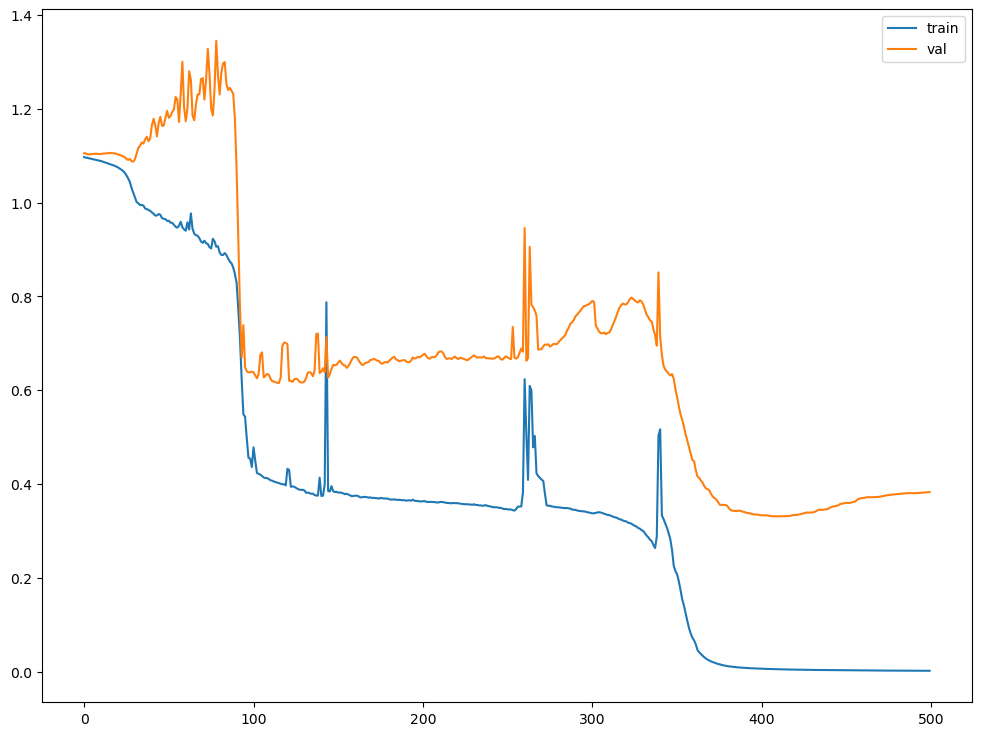

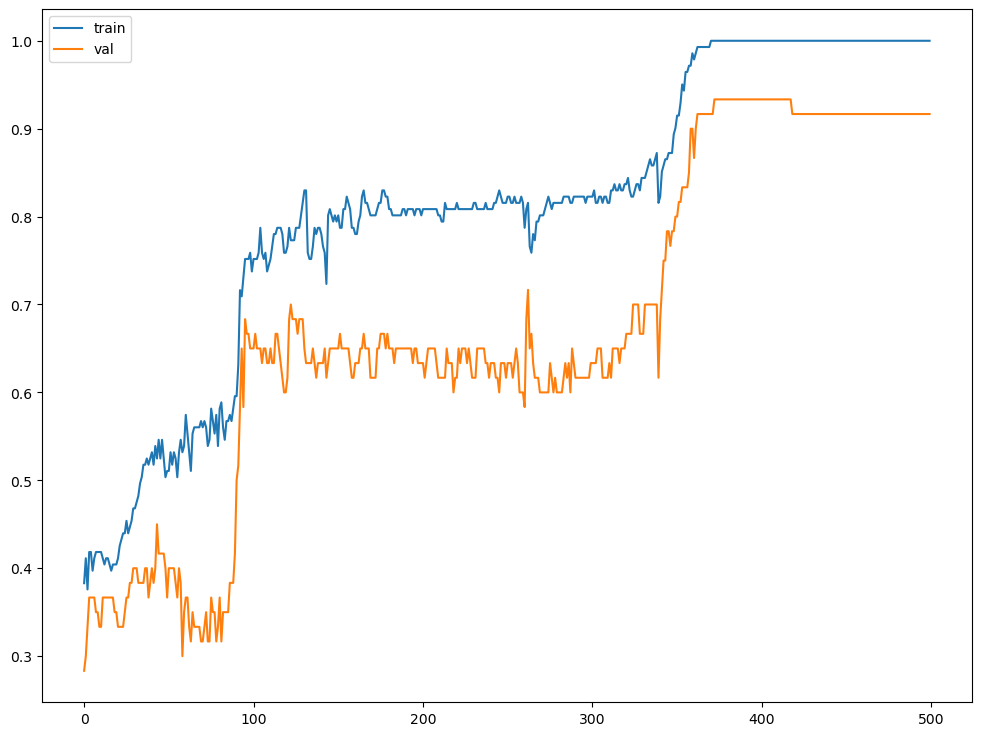

In [26]:
plt.figure(figsize=(12, 9))
plt.plot(hist.history["loss"], label="train")
plt.plot(hist.history["val_loss"], label="val")
plt.legend()
plt.show()


plt.figure(figsize=(12, 9))
plt.plot(hist.history["accuracy"], label="train")
plt.plot(hist.history["val_accuracy"], label="val")
plt.legend()
plt.show()

cyl: 0.000057
bell: 0.000443
fun: 0.999501



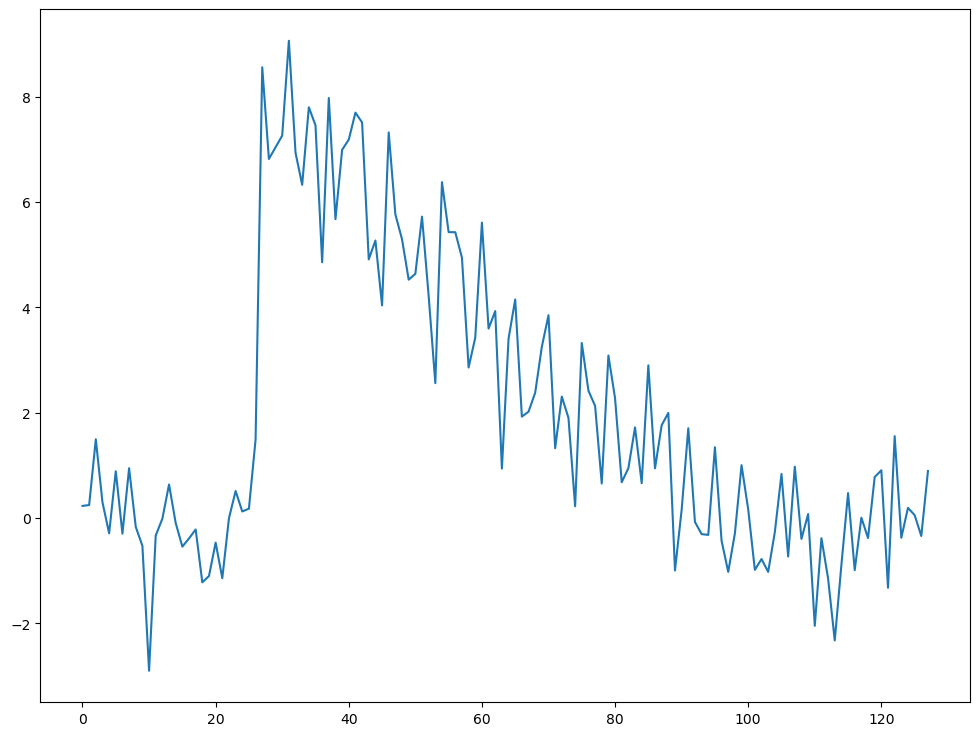

In [27]:
i = 0
pred = predict_classifier(gru, X_train[i:i+1]).ravel()
print("cyl: %f\nbell: %f\nfun: %f\n" % (pred[0], pred[1], pred[2]))
plt.figure(figsize=(12, 9))
plt.plot(X_train[i].ravel())
plt.show()


## Forecasting

### Dataset

**Monthly Sunspot Dataset**

This dataset describes a monthly count of the number of observed sunspots for just over 230 years (1749-1983).
The units are a count and there are 2,820 observations. The source of the dataset is credited to Andrews & Herzberg (1985).

In [28]:
x_orig = pd.read_csv("https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly-sunspots.csv", index_col="Month")

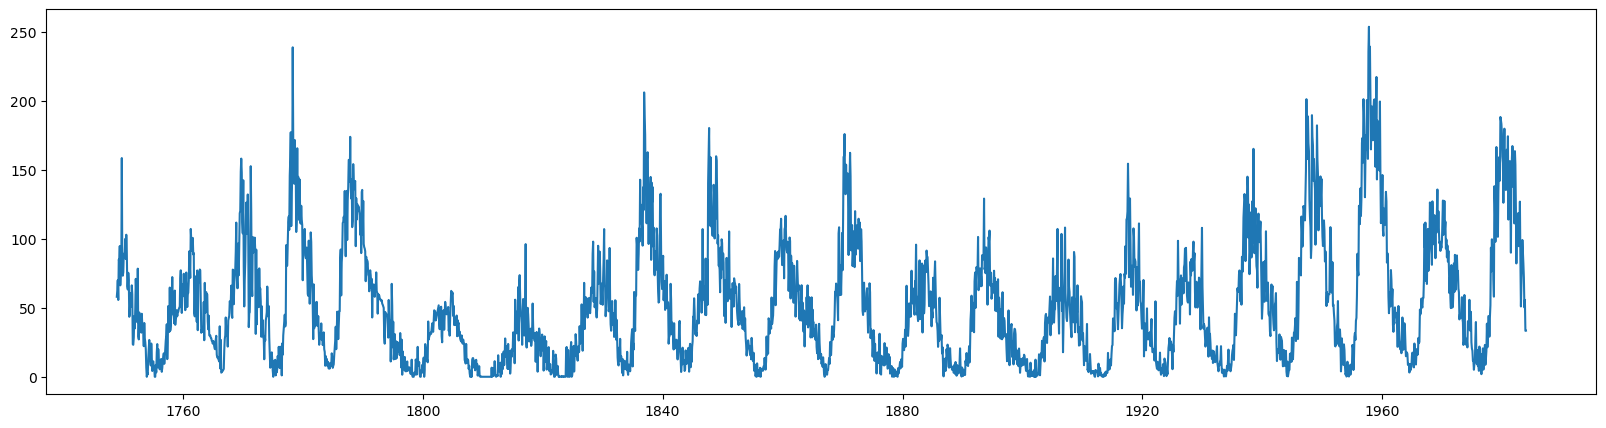

In [29]:
plt.figure(figsize=(20,5))
plt.plot(pd.to_datetime(x_orig.index), np.array(x_orig))
plt.show()

In [30]:
def split_sequence(y,w):
    XX = np.array([y[i:i+w] for i in range(len(y)-w)])
    YY = np.array(y[w:])
    return XX, YY

A sliding window turns a single time series into supervised examples.

For a window of width `w`, the input is `[x_t, x_{t+1}, ..., x_{t+w-1}]` and the target is `x_{t+w}`.


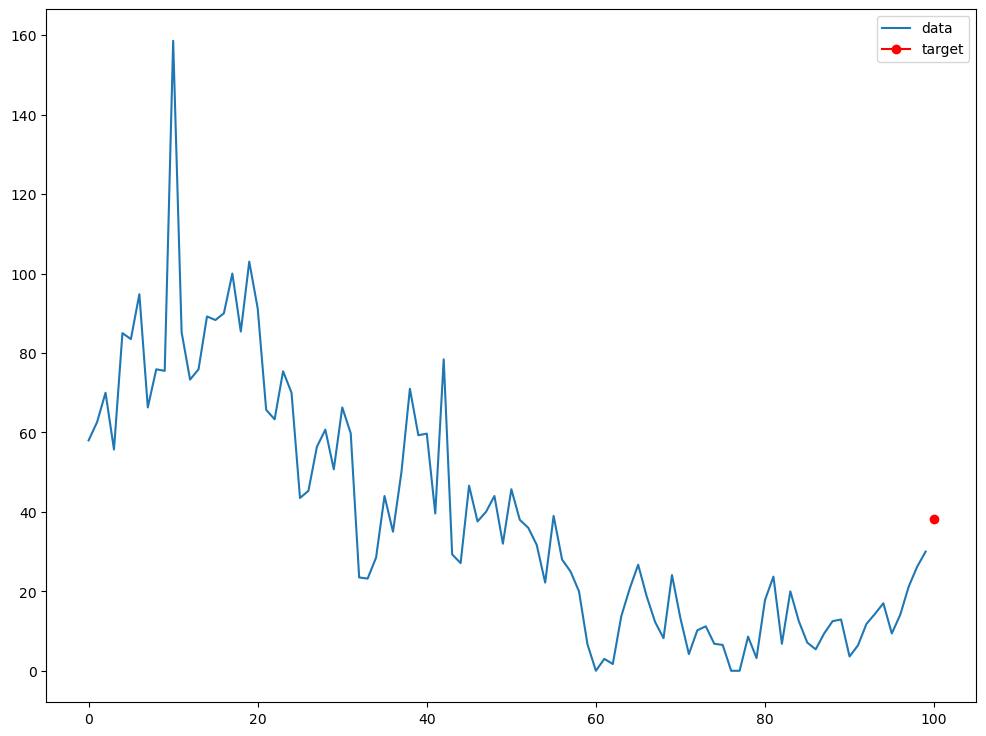

In [31]:
plt.figure(figsize=(12, 9))
plt.plot(np.array(x_orig[:100]), label="data")
plt.plot(100, np.array(x_orig)[100], c="red", marker="o", label="target")
plt.legend()
plt.show()

In [32]:
x = (np.array(x_orig) - np.array(x_orig).min()) / (np.array(x_orig).max() - np.array(x_orig).min())  # scale values between 0 and 1
n_steps_in = 100  # choose window size
X, y = split_sequence(x, n_steps_in)  # create windowed time series
X.shape

(2720, 100, 1)

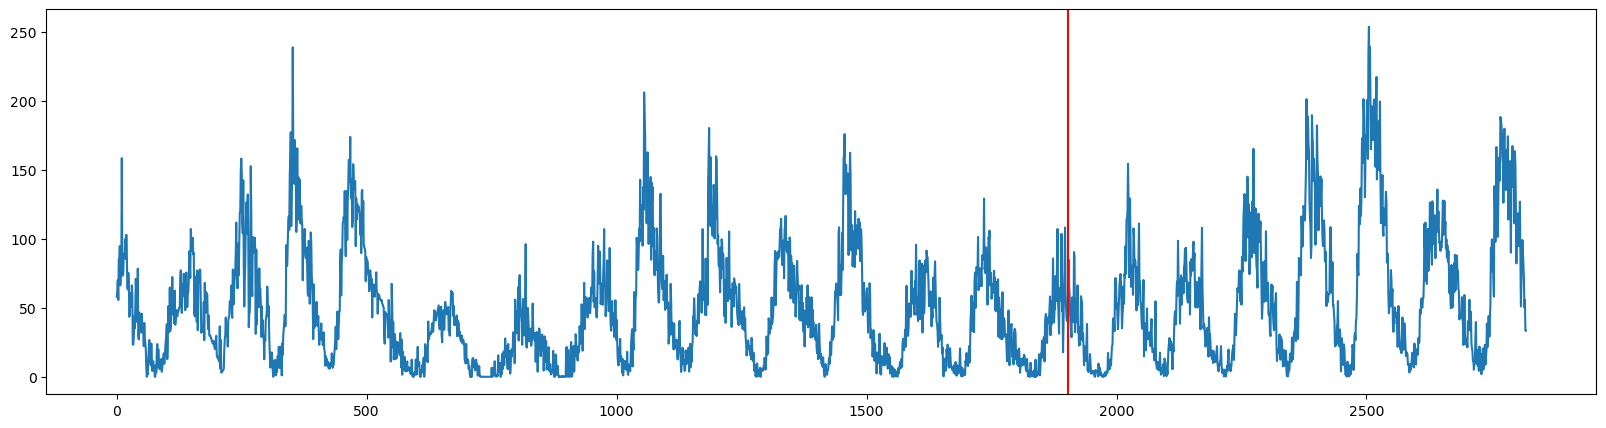

In [33]:
split_idx = int(len(X) * 0.7)  # idx to split in train/test
X_train = X[:split_idx]
X_test = X[split_idx:]
y_train = y[:split_idx]
y_test = y[split_idx:]

plt.figure(figsize=(20,5))
plt.plot(np.array(x_orig))
plt.axvline(split_idx, c="red")
plt.show()

In [34]:
X_train.shape

(1903, 100, 1)

### Deep Encoder-Decoder RNN

For building a deep encoder-decoder recurrent network in PyTorch we define the operations explicitly:

- an encoder recurrent layer reads the input sequence;
- a decoder recurrent layer receives the encoder context;
- a shared `nn.Linear` layer maps each decoder output to the forecast value.

For multi-step forecasting the context vector can be repeated along the time dimension before passing it to the decoder.


![](https://i.stack.imgur.com/LNXjF.jpg)

In PyTorch, `nn.Linear` can be applied directly to a tensor shaped `(batch, time, hidden_size)`.

The same linear weights are used at every time step, so no wrapper layer is needed.


In [35]:
class DeepEncoderDecoderRNN(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, output_size=1, out_steps=1):
        super().__init__()
        self.out_steps = out_steps
        self.encoder = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.decoder = nn.GRU(hidden_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
        init_input_identity(self.encoder, gain=1.0)
        init_input_identity(self.decoder, gain=1.0)

    def forward(self, x):
        encoder_out, _ = self.encoder(x)
        context = encoder_out[:, -1:, :].repeat(1, self.out_steps, 1)
        decoder_out, _ = self.decoder(context)
        forecast = self.fc(decoder_out)
        return forecast.squeeze(1)


model = DeepEncoderDecoderRNN(input_size=1, hidden_size=32, output_size=1, out_steps=1).to(device)
summarize_model(model, input_shape=(1, n_steps_in, 1))


DeepEncoderDecoderRNN(
  (encoder): LSTM(1, 32, batch_first=True)
  (decoder): GRU(32, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)
Trainable parameters: 10,849
Input shape: (1, 100, 1)
Output shape: (1, 1)


In [37]:
hist = train_regressor(model, X_train, y_train, epochs=30, validation_split=.3)

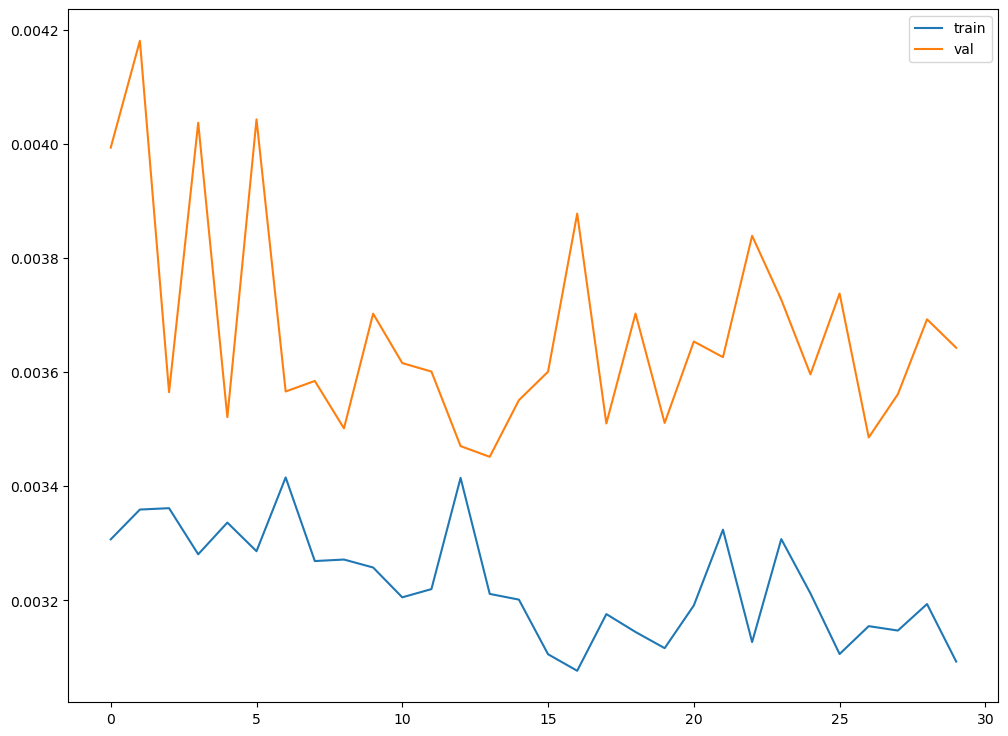

In [38]:
plt.figure(figsize=(12, 9))
plt.plot(hist.history["loss"], label="train")
plt.plot(hist.history["val_loss"], label="val")
plt.legend()
plt.show()

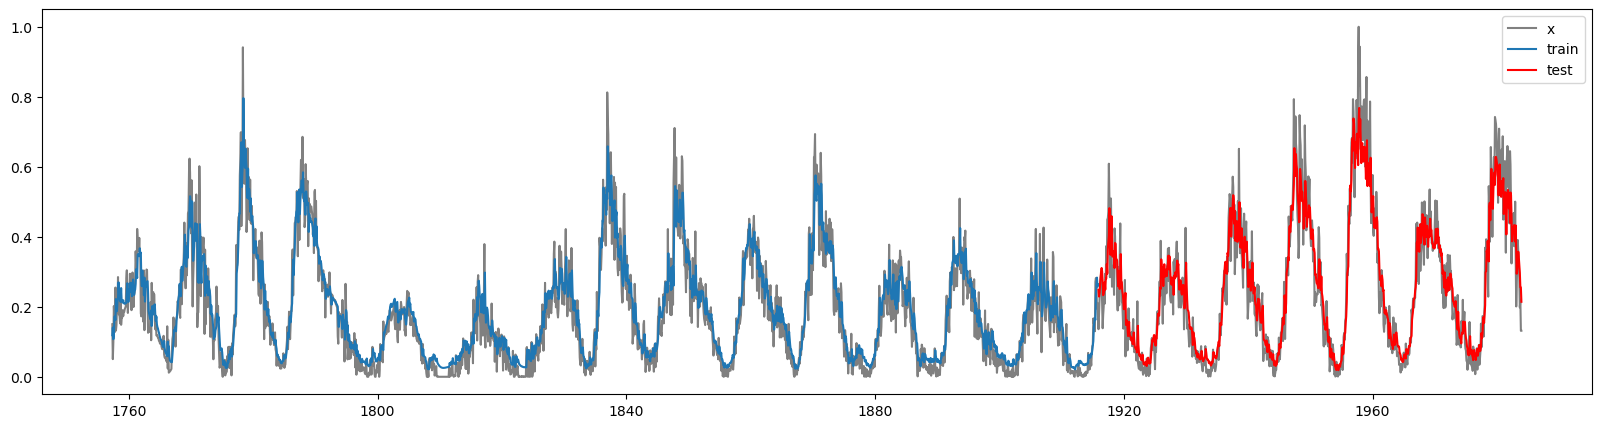

In [39]:
y_pred = predict_regressor(model, X)
idx = pd.to_datetime(x_orig.index)[n_steps_in:]
plt.figure(figsize=(20,5))
plt.plot(idx, x[n_steps_in:], c="gray", label="x")
plt.plot(idx[:split_idx], y_pred.ravel()[:split_idx], label="train")
plt.plot(idx[split_idx:], y_pred.ravel()[split_idx:], c="r", label="test")
#plt.plot(y_pred.ravel())
plt.legend()
plt.show()
